# Lab 06 — NLP Foundations: Handwriting OCR Evaluation

Tesseract OCR is evaluated on 89 labelled photographs of handwritten medicine names. The
lab builds a reproducible benchmark, tests one controlled preprocessing change, and
analyses the failures. Image preprocessing is a computer-vision step; text normalisation
and edit distance provide the text-level evaluation.

**How to run.** Open this notebook from the `all_experiments` folder and choose *Run All*.
Evidence is written to `results/lab06/`.

**Prerequisite.** `pytesseract` is only a wrapper: the Tesseract engine must be installed
(Windows `winget install --id UB-Mannheim.TesseractOCR`, Ubuntu `sudo apt-get install
tesseract-ocr`, macOS `brew install tesseract`) and the kernel restarted afterwards.

**Questions**

1. Validate the archive.
2. Run the baseline OCR.
3. Measure recognition quality.
4. Build one preprocessing pipeline.
5. Compare the two pipelines fairly.
6. Analyse the failures.

## Setup

In [1]:
import re
import shutil
import zipfile
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pytesseract
from IPython.display import display
from PIL import Image, ImageOps

ROOT = Path.cwd().parent
DATA = ROOT / "all_datasets"
RESULTS = ROOT / "results" / "lab06"
RESULTS.mkdir(parents=True, exist_ok=True)

# The engine is found on PATH or in the default Windows install folder.
tesseract = shutil.which("tesseract") or r"C:\Program Files\Tesseract-OCR\tesseract.exe"
pytesseract.pytesseract.tesseract_cmd = tesseract
print("Tesseract", pytesseract.get_tesseract_version(), "at", tesseract)

Tesseract 5.5.3.20260724 at C:\Program Files\Tesseract-OCR\tesseract.EXE


## Question 1 — Validate the archive

Extract the archive next to itself, load the label file, check that all 89 labelled images
exist exactly once, report the number of unique labels, and show a 3-by-3 sample grid.

Labelled images: 89 | unique labels: 61


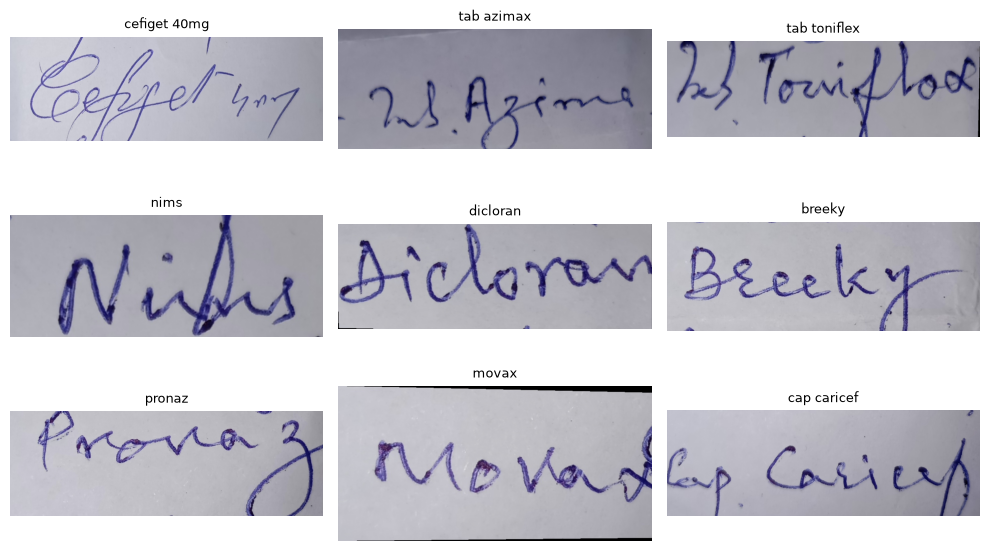

In [2]:
IMAGES = DATA / "lab06-ocr-handwritten-prescription"
if not IMAGES.exists():
    zipfile.ZipFile(DATA / "lab06-ocr-handwritten-prescription.zip").extractall(IMAGES)

labels = pd.read_csv(IMAGES / "doctor_handwriting_labels.csv")
labels["path"] = [IMAGES / "img" / "img" / name for name in labels.filename]
assert len(labels) == 89 and labels.filename.is_unique and all(p.exists() for p in labels.path)
print("Labelled images:", len(labels), "| unique labels:", labels.label.nunique())

fig, axes = plt.subplots(3, 3, figsize=(10, 6))
for ax, row in zip(axes.flat, labels.head(9).itertuples()):
    ax.imshow(Image.open(row.path))
    ax.set_title(row.label, fontsize=9)
    ax.axis("off")
plt.tight_layout()
plt.savefig(RESULTS / "sample_grid.png", dpi=150)

**Answer.** One label file and 89 photographs, each present exactly once; the 89 labels
hold 61 distinct medicine names, so some names appear several times in different
handwriting. The grid shows what the engine faces: cursive, varied stroke width, uneven
lighting and lined paper.

## Question 2 — Run the baseline OCR

Use one fixed Tesseract configuration for every raw image (LSTM engine, page-segmentation
mode 7 = one text line) and normalise both prediction and label to lowercase letters and
digits, so punctuation and spacing do not count as errors.

In [3]:
OCR_CONFIG = "--oem 1 --psm 7"


def normalise(text):
    return re.sub(r"[^a-z0-9]", "", str(text).lower())


def run_ocr(paths, pipeline):
    """One row per image: the raw prediction and its normalised form."""
    rows = []
    for row, path in zip(labels.itertuples(), paths):
        prediction = pytesseract.image_to_string(Image.open(path), config=OCR_CONFIG).strip()
        rows.append({"filename": row.filename, "pipeline": pipeline, "truth": row.label, "prediction": prediction,
                     "truth_norm": normalise(row.label), "prediction_norm": normalise(prediction)})
    return pd.DataFrame(rows)


baseline = run_ocr(labels.path, "baseline")
display(baseline[["truth", "prediction", "prediction_norm"]].head(8))

,truth,prediction,prediction_norm
0,cefiget 40mg,,
1,tab azimax,Ago,ago
2,tab toniflex,p53 Towid host,p53towidhost
3,nims,Nidu,nidu
4,dicloran,divlarew,divlarew
5,breeky,,
6,pronaz,,
7,movax,Ap Vos,apvos


**Answer.** The first rows already show the two failure modes the lab will quantify:
images where Tesseract returns nothing, and images where it returns text that shares only
a few characters with the label. The configuration is now fixed, so any later improvement
must come from the image, not from tuning the engine.

## Question 3 — Measure recognition quality

Implement Levenshtein edit distance and report, for the baseline: exact-match accuracy,
mean normalised edit distance (distance divided by the longer string, so it lies in 0–1),
character error rate (total edits divided by total reference characters; it can exceed 1),
and the number of blank predictions.

In [4]:
def levenshtein(a, b):
    """Minimum number of single-character edits that turn a into b."""
    previous = list(range(len(b) + 1))
    for i, char_a in enumerate(a, start=1):
        current = [i]
        for j, char_b in enumerate(b, start=1):
            current.append(min(current[j - 1] + 1, previous[j] + 1, previous[j - 1] + (char_a != char_b)))
        previous = current
    return previous[-1]


def add_distances(frame):
    frame = frame.copy()
    frame["exact"] = frame.truth_norm == frame.prediction_norm
    frame["edits"] = [levenshtein(t, p) for t, p in zip(frame.truth_norm, frame.prediction_norm)]
    longest = np.maximum(frame.truth_norm.str.len(), frame.prediction_norm.str.len()).clip(lower=1)
    frame["normalised_edit_distance"] = frame.edits / longest
    return frame


def summarise(frame):
    return {"pipeline": frame.pipeline.iat[0],
            "exact_match_accuracy": frame.exact.mean(),
            "mean_normalised_edit_distance": frame.normalised_edit_distance.mean(),
            "character_error_rate": frame.edits.sum() / frame.truth_norm.str.len().sum(),
            "blank_predictions": int((frame.prediction_norm == "").sum())}


baseline = add_distances(baseline)
display(pd.DataFrame([summarise(baseline)]).round(4))

,pipeline,exact_match_accuracy,mean_normalised_edit_distance,character_error_rate,blank_predictions
0,baseline,0.0,0.8559,0.8753,39


**Answer.** Generic OCR on raw handwriting is poor: none of the 89 names is read exactly,
the character error rate is close to 0.9, and about half the images yield no text at all.
The metrics are reproducible because the normalisation and the distance are written out
rather than taken from a library with hidden options.

## Question 4 — Build one preprocessing pipeline

Convert each image to grayscale, add a 20-pixel white border, cap the width at 1,200 pixels,
and enlarge by 1.5x with bicubic resampling. Save the results under
`results/lab06/preprocessed/`. The OCR configuration does not change.

In [5]:
def preprocess(path, output):
    image = ImageOps.exif_transpose(Image.open(path)).convert("L")
    image = ImageOps.expand(image, border=20, fill=255)
    if image.width > 1200:
        image = image.resize((1200, round(image.height * 1200 / image.width)), Image.Resampling.LANCZOS)
    image = image.resize((round(image.width * 1.5), round(image.height * 1.5)), Image.Resampling.BICUBIC)
    image.save(output)
    return output


(RESULTS / "preprocessed").mkdir(exist_ok=True)
preprocessed_paths = [preprocess(path, RESULTS / "preprocessed" / f"{i:03d}.png") for i, path in enumerate(labels.path)]
example = Image.open(preprocessed_paths[0])
print("Prepared images:", len(preprocessed_paths), "| example size:", example.size, "mode:", example.mode)

Prepared images: 89 | example size: (1800, 638) mode: L


**Answer.** Each step targets a known weakness of Tesseract on photographs: grayscale
removes colour noise, the border stops text touching the edge (which breaks line
segmentation), the width cap bounds runtime, and the enlargement brings stroke height into
the range the engine was trained on. Only the image changes; the engine settings do not.

## Question 5 — Compare the two pipelines fairly

Run OCR on the preprocessed images with the identical configuration, keep exactly the same
89 samples, save one row per image and pipeline to `predictions.csv`, and save both sets of
metrics to `metrics.csv`.

In [6]:
preprocessed = add_distances(run_ocr(preprocessed_paths, "grayscale_border_resize"))
pd.concat([baseline, preprocessed]).to_csv(RESULTS / "predictions.csv", index=False)

metrics = pd.DataFrame([summarise(baseline), summarise(preprocessed)]).set_index("pipeline")
metrics.to_csv(RESULTS / "metrics.csv")
display(metrics.round(4))
display((metrics.loc["grayscale_border_resize"] - metrics.loc["baseline"]).rename("change").round(3).to_frame())

,exact_match_accuracy,mean_normalised_edit_distance,character_error_rate,blank_predictions
pipeline,,,,
baseline,0.0000,0.8559,0.8753,39
grayscale_border_resize,0.0112,0.7673,0.7883,15


,change
exact_match_accuracy,0.011
mean_normalised_edit_distance,-0.089
character_error_rate,-0.087
blank_predictions,-24.000


**Answer.** Preprocessing cuts the blank predictions from 39 to 15 and lowers the
character error rate by about 0.09, but exact-match accuracy barely moves (one correct
name out of 89): the engine now *sees* text on most images yet still cannot read cursive.
Because both pipelines were scored on the same 89 images with the same configuration, the
difference is attributable to the preprocessing alone. Exact numbers depend on the
Tesseract version; the direction of the changes does not.

## Question 6 — Analyse the failures

Take the worst preprocessed predictions by normalised edit distance, tag each one as *no
text detected* or *character confusion*, save the table as `error_analysis.csv`, and save a
figure of the six hardest images.

,truth,prediction,failure_type
60,azitma,,no text detected
61,tonoflox,,no text detected
0,cefiget 40mg,,no text detected
5,breeky,,no text detected
13,tab nims 100mg,,no text detected
17,cap caricef 40mg,,no text detected
19,tab novidat,| i» jell,character confusion
21,tab atcomid,|,no text detected


Saved: ['error_analysis.csv', 'metrics.csv', 'ocr_failures.png', 'predictions.csv', 'sample_grid.png']


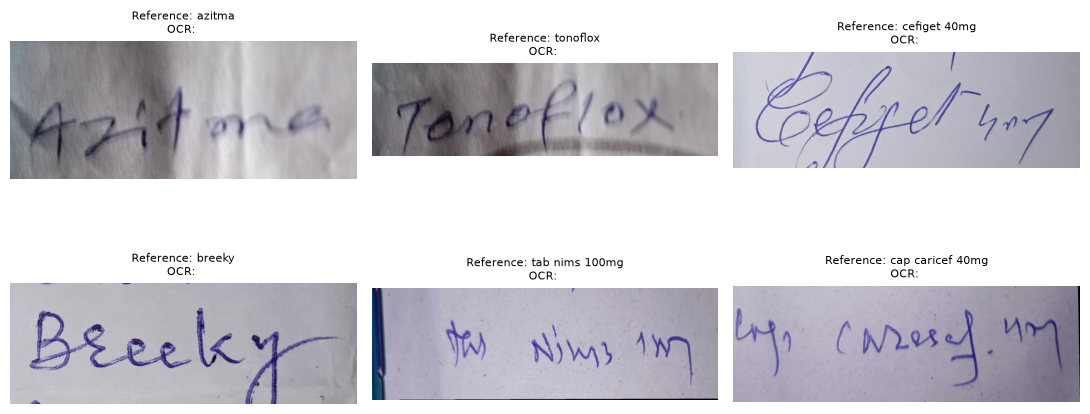

In [7]:
errors = preprocessed[~preprocessed.exact].sort_values(["normalised_edit_distance", "filename"], ascending=[False, True]).head(8)
errors = errors.assign(failure_type=np.where(errors.prediction_norm == "", "no text detected", "character confusion"))
errors[["filename", "truth", "prediction", "failure_type"]].to_csv(RESULTS / "error_analysis.csv", index=False)
display(errors[["truth", "prediction", "failure_type"]])

fig, axes = plt.subplots(2, 3, figsize=(11, 5.5))
for ax, row in zip(axes.flat, errors.head(6).itertuples()):
    ax.imshow(Image.open(IMAGES / "img" / "img" / row.filename))
    ax.set_title(f"Reference: {row.truth}\nOCR: {row.prediction[:28]}", fontsize=8)
    ax.axis("off")
plt.tight_layout()
plt.savefig(RESULTS / "ocr_failures.png", dpi=150)
print("Saved:", sorted(p.name for p in RESULTS.iterdir() if p.is_file()))

**Answer.** The hardest cases split into two kinds. *No text detected* is a segmentation
failure — faint strokes, low contrast or slanted writing that the line finder rejects.
*Character confusion* is a recognition failure — a line is found but cursive shapes are
mapped to the wrong printed letters. Preprocessing helps the first kind and barely touches
the second, which is why exact-match accuracy stays low.

This is a benchmark of model–domain fit, not evidence that generic OCR suits clinical
transcription. A medical system would need a handwriting-specific recogniser,
representative data, external validation, privacy controls and mandatory human
verification, and must never decide medication or dosage from uncertain text.